In [ ]:
from pathlib import Path

from IPython.display import Image, Markdown, display



STATIC_IMAGE_DIR = Path("/kaggle/input/notebook-static-images-public")

display(Markdown("## Saved analysis figures"))

for image_path in sorted(STATIC_IMAGE_DIR.glob("xenium-*.png")):

    display(Markdown(f"**{image_path.stem}**"))

    display(Image(filename=str(image_path)))

In [1]:
from pathlib import Path
import warnings

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy import sparse

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = Path("/home/Data_Drive_8TB/kykim/7. Kaggle/Imputation_Benchmarking_(Xenium_Fold_1)")
XENIUM_PATH = DATA_DIR / "xenium_fold_1.h5ad"
REFERENCE_PATH = DATA_DIR / "scRNA_FFPE_Human_Breast_Cancer_Chromium_FFPE_Human_Breast_Cancer_count_sample_filtered_feature_bc_matrix.h5"
SUBMISSION_PATH = DATA_DIR / "sample_submission_fold1.csv"

assert XENIUM_PATH.exists(), XENIUM_PATH
assert REFERENCE_PATH.exists(), REFERENCE_PATH
assert SUBMISSION_PATH.exists(), SUBMISSION_PATH

In [ ]:
adata = sc.read_h5ad(XENIUM_PATH)
submission_columns = pd.read_csv(SUBMISSION_PATH, nrows=0).columns.tolist()
target_genes = pd.Index(submission_columns[1:], name="target_gene")

if submission_columns[0] != "Spot_id":
    raise ValueError("The first submission column must be 'Spot_id'.")

missing_by_gene = np.isnan(adata.X).all(axis=0)
partially_missing = np.isnan(adata.X).any(axis=0) & ~missing_by_gene
masked_genes = adata.var_names[missing_by_gene]
observed_genes = adata.var_names[~missing_by_gene]

assert not partially_missing.any(), "Unexpected partial missingness detected."
assert set(masked_genes) == set(target_genes), "Submission targets and masked genes differ."
assert len(observed_genes) + len(masked_genes) == adata.n_vars

print(f"Xenium cells: {adata.n_obs:,}")
print(f"Xenium panel genes: {adata.n_vars}")
print(f"Observed genes: {len(observed_genes)}")
print(f"Masked target genes: {len(masked_genes)}")
print(f"Spatial coordinates: {adata.obsm['spatial'].shape}")
print(f"Existing Leiden clusters: {adata.obs['leiden'].nunique()}")

Xenium cells: 166,363
Xenium panel genes: 313
Observed genes: 208
Masked target genes: 105
Spatial coordinates: (166363, 2)
Existing Leiden clusters: 11


,metric,value
0,cells,166363.00000
1,observed_genes,208.00000
2,masked_genes,105.00000
3,median_observed_counts,197.18924
4,median_detected_genes,42.00000


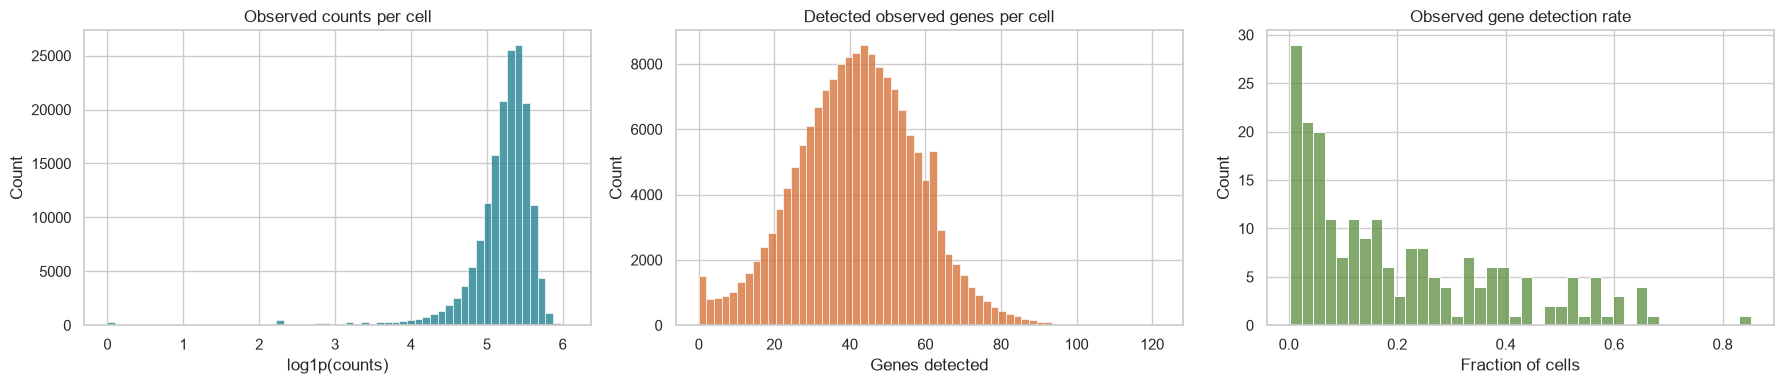

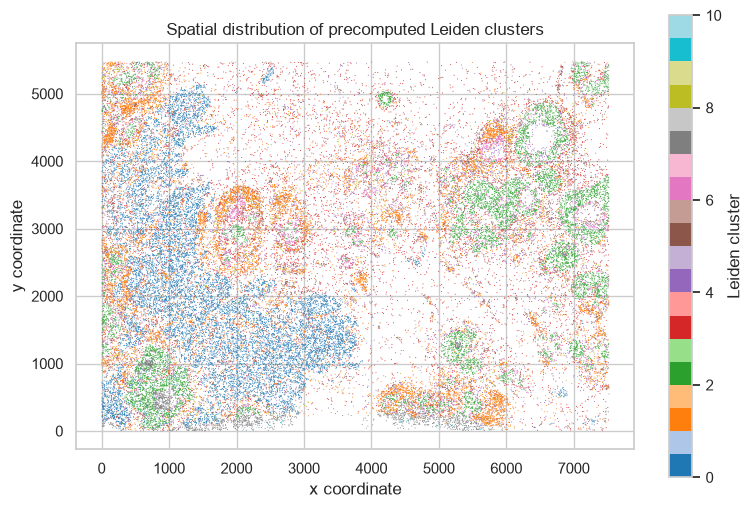

In [3]:
X_observed = np.asarray(adata[:, observed_genes].X, dtype=np.float32)
cell_total = X_observed.sum(axis=1)
detected_genes = (X_observed > 0).sum(axis=1)
gene_total = X_observed.sum(axis=0)
gene_detection_rate = (X_observed > 0).mean(axis=0)

qc_summary = pd.DataFrame(
    {
        "metric": ["cells", "observed_genes", "masked_genes", "median_observed_counts", "median_detected_genes"],
        "value": [adata.n_obs, len(observed_genes), len(masked_genes), np.median(cell_total), np.median(detected_genes)],
    }
)
display(qc_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(np.log1p(cell_total), bins=60, ax=axes[0], color="#167a8b")
axes[0].set(title="Observed counts per cell", xlabel="log1p(counts)")
sns.histplot(detected_genes, bins=60, ax=axes[1], color="#d36b2d")
axes[1].set(title="Detected observed genes per cell", xlabel="Genes detected")
sns.histplot(gene_detection_rate, bins=40, ax=axes[2], color="#5b8c3e")
axes[2].set(title="Observed gene detection rate", xlabel="Fraction of cells")
plt.tight_layout()

coordinates = adata.obsm["spatial"]
sample_index = np.random.default_rng(42).choice(adata.n_obs, size=min(50_000, adata.n_obs), replace=False)
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    coordinates[sample_index, 0], coordinates[sample_index, 1],
    c=adata.obs["leiden"].astype(int).to_numpy()[sample_index],
    s=0.5, cmap="tab20", linewidths=0, rasterized=True,
 )
ax.set(title="Spatial distribution of precomputed Leiden clusters", xlabel="x coordinate", ylabel="y coordinate", aspect="equal")
fig.colorbar(scatter, ax=ax, label="Leiden cluster")
plt.show()

/home/Data_Drive_8TB/kykim/.conda/envs/scrna/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/Data_Drive_8TB/kykim/.conda/envs/scrna/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Reference cells x genes: 30,365 x 18,082
Shared genes: 307 / 313
Reference-supported observed genes: 207 / 208
Reference-supported target genes: 100 / 105
Genes with |r| >= 0.30 partner: 61.9%
Gene-pairs with |r| >= 0.20: 7.7%


/home/Data_Drive_8TB/kykim/.conda/envs/scrna/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/Data_Drive_8TB/kykim/.conda/envs/scrna/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_664742/3810396193.py:30: RuntimeWarning: All-NaN slice encountered
  strong_partner_fraction = np.nanmean(np.nanmax(absolute_correlation, axis=1) >= 0.30)


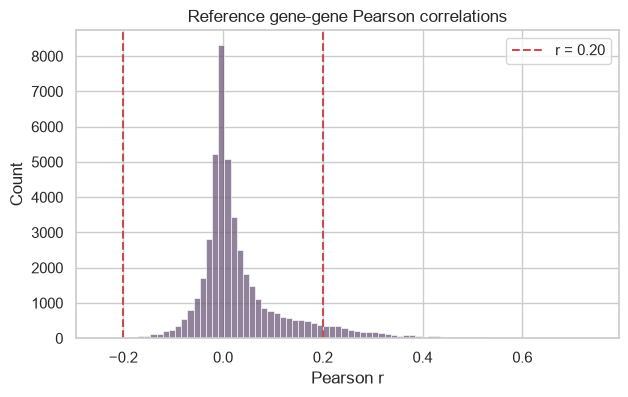

In [4]:
reference = sc.read_10x_h5(REFERENCE_PATH, gex_only=True)
reference.var_names_make_unique()
reference.var_names = reference.var_names.str.upper()
xenium_gene_set = pd.Index(adata.var_names.str.upper())
target_gene_set = pd.Index(target_genes.str.upper())
observed_gene_set = pd.Index(observed_genes.str.upper())
reference_gene_set = pd.Index(reference.var_names)

shared_genes = xenium_gene_set.intersection(reference_gene_set)
shared_observed = observed_gene_set.intersection(reference_gene_set)
shared_targets = target_gene_set.intersection(reference_gene_set)

print(f"Reference cells x genes: {reference.n_obs:,} x {reference.n_vars:,}")
print(f"Shared genes: {len(shared_genes)} / {adata.n_vars}")
print(f"Reference-supported observed genes: {len(shared_observed)} / {len(observed_genes)}")
print(f"Reference-supported target genes: {len(shared_targets)} / {len(target_genes)}")

reference_subset = reference[:, shared_genes].copy()
sc.pp.normalize_total(reference_subset, target_sum=1e4)
sc.pp.log1p(reference_subset)
rng = np.random.default_rng(42)
reference_sample = rng.choice(reference_subset.n_obs, size=min(10_000, reference_subset.n_obs), replace=False)
reference_expression = reference_subset.X[reference_sample]
if sparse.issparse(reference_expression):
    reference_expression = reference_expression.toarray()
reference_correlation = np.corrcoef(reference_expression, rowvar=False)
np.fill_diagonal(reference_correlation, np.nan)

absolute_correlation = np.abs(reference_correlation)
strong_partner_fraction = np.nanmean(np.nanmax(absolute_correlation, axis=1) >= 0.30)
pair_fraction = np.nanmean(absolute_correlation[np.triu_indices_from(absolute_correlation, k=1)] >= 0.20)
print(f"Genes with |r| >= 0.30 partner: {strong_partner_fraction:.1%}")
print(f"Gene-pairs with |r| >= 0.20: {pair_fraction:.1%}")

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(reference_correlation[np.triu_indices_from(reference_correlation, k=1)], bins=80, ax=ax, color="#6d597a")
ax.axvline(0.20, color="#c44e52", linestyle="--", label="r = 0.20")
ax.axvline(-0.20, color="#c44e52", linestyle="--")
ax.set(title="Reference gene-gene Pearson correlations", xlabel="Pearson r")
ax.legend()
plt.show()

n_cells  median_observed_counts  cluster_entropy  roi_score
tile_x tile_y                                                             
0      1          6911              184.429993             1.96     136.75
       4          7244              187.929993             1.79     130.09
1      0          5585              180.220001             1.90     130.05
2      2          4671              188.559998             1.93     129.80
0      2          7337              195.600006             1.75     129.13
       0          8049              181.410004             1.75     128.65
5      3          6389              200.210007             1.74     127.42
6      4          4819              214.270004             1.75     125.13
1      2          6129              205.559998             1.68     124.75
6      3          5898              207.149994             1.69     124.66

Selected ROI tile: (0, 1)
Selected ROI cells: 6,911
Selected ROI median observed counts: 184.4
ROI rationale: high cell support, high observed-expression depth, and heterogeneous Leiden composition.


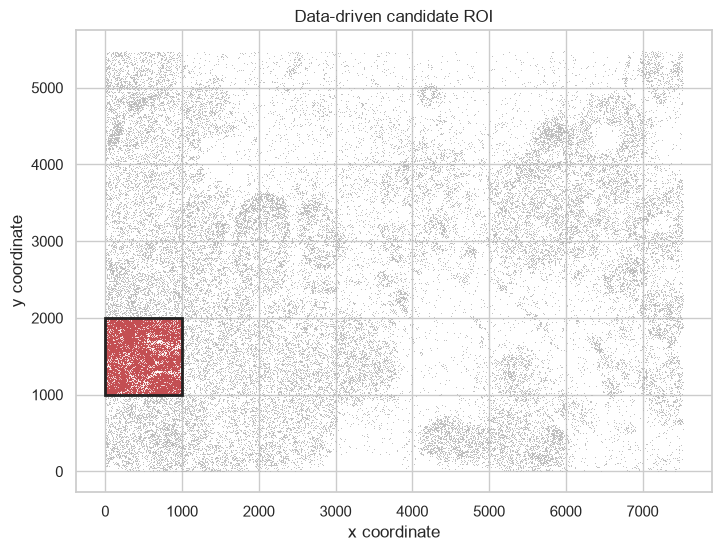

In [6]:
ROI_TILE_SIZE = 1_000
roi_frame = pd.DataFrame(
    {
        "x": coordinates[:, 0],
        "y": coordinates[:, 1],
        "observed_counts": cell_total,
        "leiden": adata.obs["leiden"].astype(str).to_numpy(),
    },
    index=adata.obs_names,
 )
roi_frame["tile_x"] = (roi_frame["x"] // ROI_TILE_SIZE).astype(int)
roi_frame["tile_y"] = (roi_frame["y"] // ROI_TILE_SIZE).astype(int)

tile_summary = roi_frame.groupby(["tile_x", "tile_y"], observed=True).agg(
    n_cells=("x", "size"),
    median_observed_counts=("observed_counts", "median"),
 )
cluster_proportions = pd.crosstab(
    [roi_frame["tile_x"], roi_frame["tile_y"]], roi_frame["leiden"], normalize="index"
 )
tile_summary["cluster_entropy"] = -(cluster_proportions * np.log(cluster_proportions.clip(lower=1e-12))).sum(axis=1)
tile_summary["roi_score"] = (
    np.log1p(tile_summary["n_cells"]) *
    np.log1p(tile_summary["median_observed_counts"]) *
    (1 + tile_summary["cluster_entropy"])
 )
roi_candidates = tile_summary.query("n_cells >= 1000").sort_values("roi_score", ascending=False)
display(roi_candidates.head(10).round(2))

selected_tile = roi_candidates.index[0]
selected_tile_x, selected_tile_y = selected_tile
roi_mask = (roi_frame["tile_x"] == selected_tile_x) & (roi_frame["tile_y"] == selected_tile_y)
roi_cell_ids = roi_frame.index[roi_mask]
print(f"Selected ROI tile: ({selected_tile_x}, {selected_tile_y})")
print(f"Selected ROI cells: {roi_mask.sum():,}")
print(f"Selected ROI median observed counts: {roi_frame.loc[roi_mask, 'observed_counts'].median():.1f}")
print("ROI rationale: high cell support, high observed-expression depth, and heterogeneous Leiden composition.")

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(coordinates[sample_index, 0], coordinates[sample_index, 1], s=0.4, color="#b8b8b8", linewidths=0, rasterized=True)
ax.scatter(roi_frame.loc[roi_mask, "x"], roi_frame.loc[roi_mask, "y"], s=0.8, color="#c44e52", linewidths=0, rasterized=True)
roi_rectangle = plt.Rectangle(
    (selected_tile_x * ROI_TILE_SIZE, selected_tile_y * ROI_TILE_SIZE),
    ROI_TILE_SIZE, ROI_TILE_SIZE, fill=False, edgecolor="#222222", linewidth=2,
 )
ax.add_patch(roi_rectangle)
ax.set(title="Data-driven candidate ROI", xlabel="x coordinate", ylabel="y coordinate", aspect="equal")
plt.show()

Hierarchical clustering genes: 306
Initial non-singleton modules: 22
Unassigned singleton genes: 56


,module,n_genes
0,Module 01,84
1,Unassigned,56
2,Module 02,27
3,Module 03,26
4,Module 04,20
5,Module 05,18
6,Module 06,16
7,Module 07,13
8,Module 08,6
9,Module 09,5


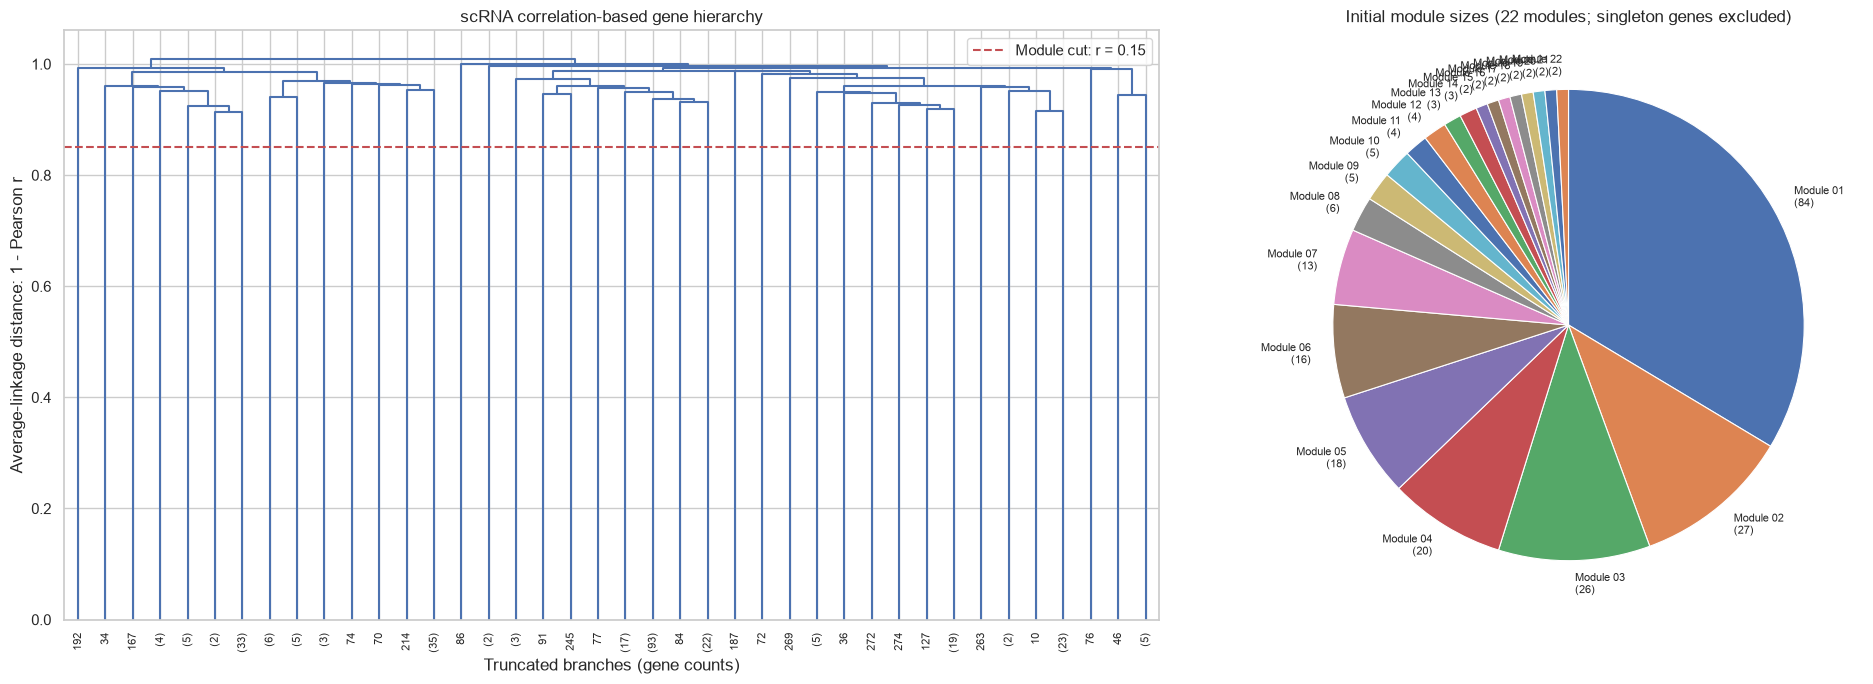

In [7]:
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import squareform

MODULE_DISTANCE_CUTOFF = 0.85
MIN_MODULE_SIZE = 2

reference_variance = np.std(reference_expression, axis=0)
valid_gene_mask = reference_variance > 1e-8
valid_module_genes = shared_genes[valid_gene_mask]
module_expression = reference_expression[:, valid_gene_mask]
module_correlation = np.corrcoef(module_expression, rowvar=False)
module_correlation = np.nan_to_num(module_correlation, nan=0.0)
np.fill_diagonal(module_correlation, 1.0)
module_distance = np.clip(1 - module_correlation, 0, 2)
module_linkage = linkage(squareform(module_distance, checks=False), method="average")
raw_module_labels = fcluster(module_linkage, t=MODULE_DISTANCE_CUTOFF, criterion="distance")

raw_sizes = pd.Series(raw_module_labels).value_counts()
retained_raw_labels = raw_sizes[raw_sizes >= MIN_MODULE_SIZE].index
module_assignment = pd.DataFrame(
    {
        "gene": valid_module_genes,
        "raw_module": raw_module_labels,
    }
)
module_assignment["module"] = np.where(
    module_assignment["raw_module"].isin(retained_raw_labels),
    module_assignment["raw_module"].astype(str),
    "Unassigned",
)
module_sizes = module_assignment.loc[module_assignment["module"] != "Unassigned", "module"].value_counts()
module_order = module_sizes.sort_values(ascending=False).index
module_name_map = {module_id: f"Module {index:02d}" for index, module_id in enumerate(module_order, start=1)}
module_assignment["module"] = module_assignment["module"].map(module_name_map).fillna("Unassigned")
module_sizes = module_assignment["module"].value_counts()
module_sizes.index.name = "module"
module_sizes.name = "n_genes"

print(f"Hierarchical clustering genes: {len(valid_module_genes)}")
print(f"Initial non-singleton modules: {len(module_name_map)}")
print(f"Unassigned singleton genes: {module_sizes['Unassigned']}")
display(module_sizes.rename_axis("module").reset_index().head(25))

fig, axes = plt.subplots(1, 2, figsize=(20, 7), gridspec_kw={"width_ratios": [1.35, 1]})
dendrogram(
    module_linkage,
    color_threshold=MODULE_DISTANCE_CUTOFF,
    truncate_mode="lastp",
    p=40,
    show_leaf_counts=True,
    leaf_rotation=90,
    ax=axes[0],
 )
axes[0].axhline(MODULE_DISTANCE_CUTOFF, color="#c44e52", linestyle="--", label="Module cut: r = 0.15")
axes[0].set(title="scRNA correlation-based gene hierarchy", xlabel="Truncated branches (gene counts)", ylabel="Average-linkage distance: 1 - Pearson r")
axes[0].legend()

pie_sizes = module_sizes[module_sizes.index != "Unassigned"]
pie_labels = [f"{module}\n({size})" for module, size in pie_sizes.items()]
axes[1].pie(
    pie_sizes,
    labels=pie_labels,
    startangle=90,
    counterclock=False,
    textprops={"fontsize": 8},
    wedgeprops={"edgecolor": "white", "linewidth": 0.8},
 )
axes[1].set(title=f"Initial module sizes ({len(pie_sizes)} modules; singleton genes excluded)")
plt.tight_layout()
plt.show()

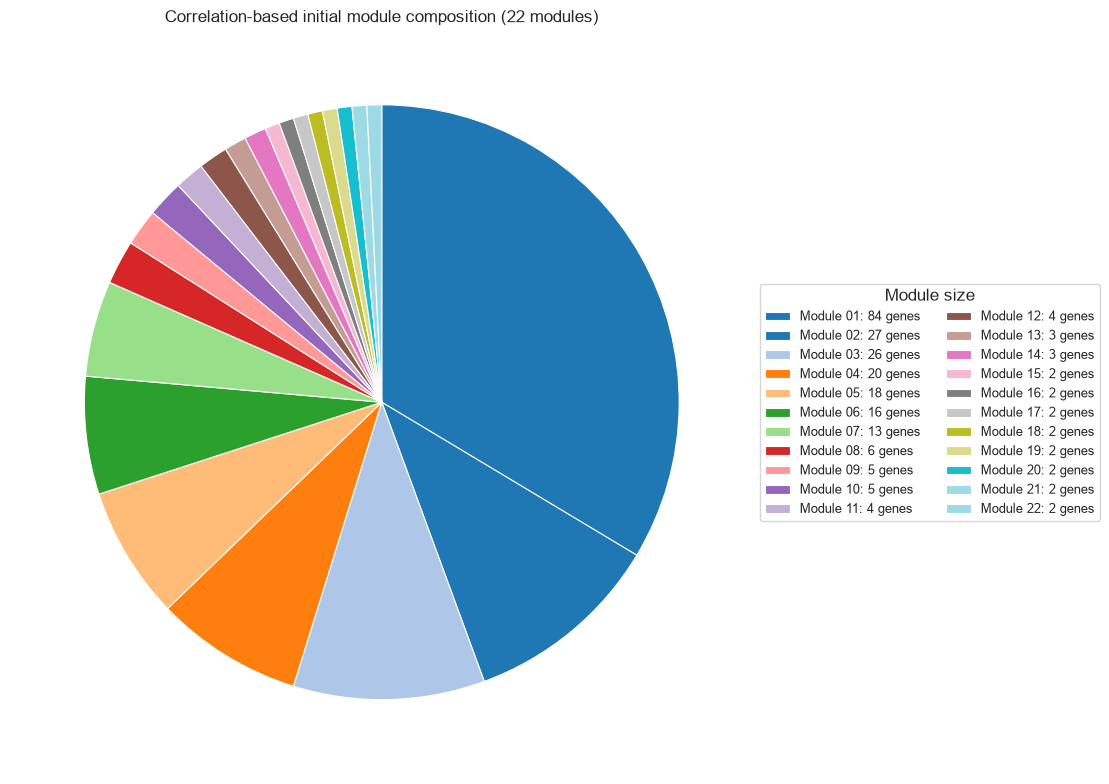

In [8]:
pie_sizes = module_sizes[module_sizes.index != "Unassigned"]
pie_colors = plt.get_cmap("tab20")(np.linspace(0, 1, len(pie_sizes)))
fig, ax = plt.subplots(figsize=(13, 8))
wedges, _ = ax.pie(
    pie_sizes,
    startangle=90,
    counterclock=False,
    colors=pie_colors,
    wedgeprops={"edgecolor": "white", "linewidth": 0.8},
 )
ax.legend(
    wedges,
    [f"{module}: {size} genes" for module, size in pie_sizes.items()],
    title="Module size",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    ncol=2,
    fontsize=9,
 )
ax.set(title=f"Correlation-based initial module composition ({len(pie_sizes)} modules)")
plt.tight_layout()
plt.show()

Seed modules: 22
High-confidence WTA assignments: 272 / 306
Ambiguous or weak genes retained as unassigned: 34


,module,n_genes
0,Module 01,89
1,Unassigned,34
2,Module 02,30
3,Module 03,27
4,Module 05,21
5,Module 04,20
6,Module 06,17
7,Module 07,12
8,Module 08,6
9,Module 11,5


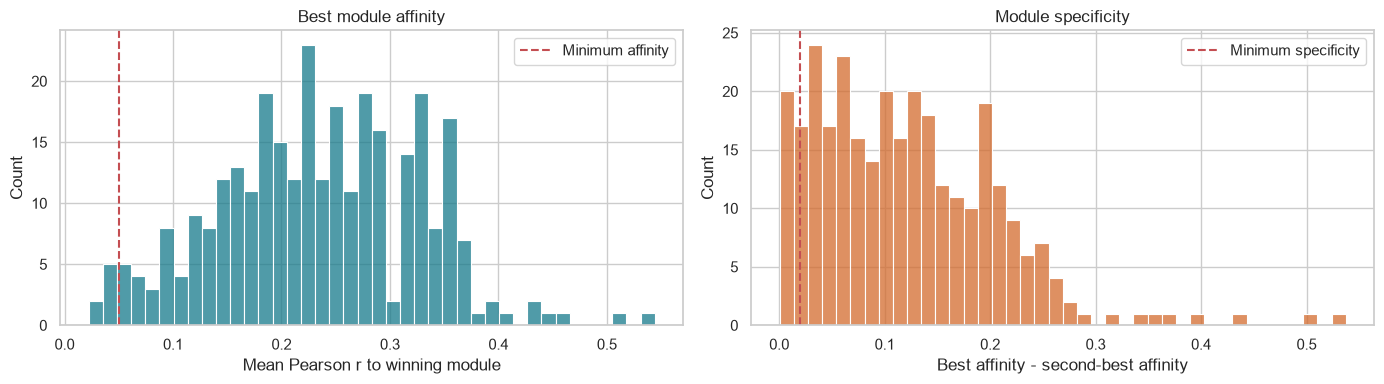

In [9]:
MIN_AFFINITY = 0.05
MIN_SPECIFICITY = 0.02

seed_modules = sorted(module_assignment.loc[module_assignment["module"] != "Unassigned", "module"].unique())
module_affinity = np.empty((len(valid_module_genes), len(seed_modules)), dtype=np.float32)
initial_module_by_gene = module_assignment.set_index("gene").loc[valid_module_genes, "module"].to_numpy()

for module_index, module_name in enumerate(seed_modules):
    member_indices = np.flatnonzero(initial_module_by_gene == module_name)
    affinities = module_correlation[:, member_indices].mean(axis=1)
    own_member_indices = member_indices
    if len(own_member_indices) > 1:
        affinities[own_member_indices] = (
            module_correlation[np.ix_(own_member_indices, own_member_indices)].sum(axis=1) - 1
        ) / (len(own_member_indices) - 1)
    module_affinity[:, module_index] = affinities

ranked_affinities = np.sort(module_affinity, axis=1)
winning_module_indices = module_affinity.argmax(axis=1)
winning_affinity = ranked_affinities[:, -1]
runner_up_affinity = ranked_affinities[:, -2]
module_specificity = winning_affinity - runner_up_affinity
high_confidence_assignment = (winning_affinity >= MIN_AFFINITY) & (module_specificity >= MIN_SPECIFICITY)
winner_module = np.array(seed_modules, dtype=object)[winning_module_indices]
winner_module[~high_confidence_assignment] = "Unassigned"

wta_assignment = pd.DataFrame(
    {
        "gene": valid_module_genes,
        "winner_module": winner_module,
        "winning_affinity": winning_affinity,
        "runner_up_affinity": runner_up_affinity,
        "specificity": module_specificity,
        "high_confidence": high_confidence_assignment,
    }
)
wta_module_sizes = wta_assignment["winner_module"].value_counts()
wta_module_sizes.index.name = "module"
wta_module_sizes.name = "n_genes"

print(f"Seed modules: {len(seed_modules)}")
print(f"High-confidence WTA assignments: {high_confidence_assignment.sum()} / {len(valid_module_genes)}")
print(f"Ambiguous or weak genes retained as unassigned: {(~high_confidence_assignment).sum()}")
display(wta_module_sizes.rename_axis("module").reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(wta_assignment["winning_affinity"], bins=40, color="#167a8b", ax=axes[0])
axes[0].axvline(MIN_AFFINITY, color="#c44e52", linestyle="--", label="Minimum affinity")
axes[0].set(title="Best module affinity", xlabel="Mean Pearson r to winning module")
axes[0].legend()
sns.histplot(wta_assignment["specificity"], bins=40, color="#d36b2d", ax=axes[1])
axes[1].axvline(MIN_SPECIFICITY, color="#c44e52", linestyle="--", label="Minimum specificity")
axes[1].set(title="Module specificity", xlabel="Best affinity - second-best affinity")
axes[1].legend()
plt.tight_layout()
plt.show()

Refined modules with >= 2 genes: 21
Higher-level modules: 16


,module,n_genes,mean_within_module_r,higher_level_module,max_cross_module_r,separation
0,Module 01,89,0.242,13,0.240,0.002
1,Module 02,30,0.246,1,0.277,-0.030
2,Module 03,27,0.205,4,0.303,-0.098
3,Module 05,21,0.217,9,0.167,0.050
4,Module 04,20,0.252,11,0.244,0.008
5,Module 06,17,0.235,13,0.336,-0.100
6,Module 07,12,0.239,8,0.129,0.110
7,Module 08,6,0.293,6,0.151,0.142
8,Module 11,5,0.247,5,0.238,0.009
9,Module 12,5,0.235,10,0.167,0.068


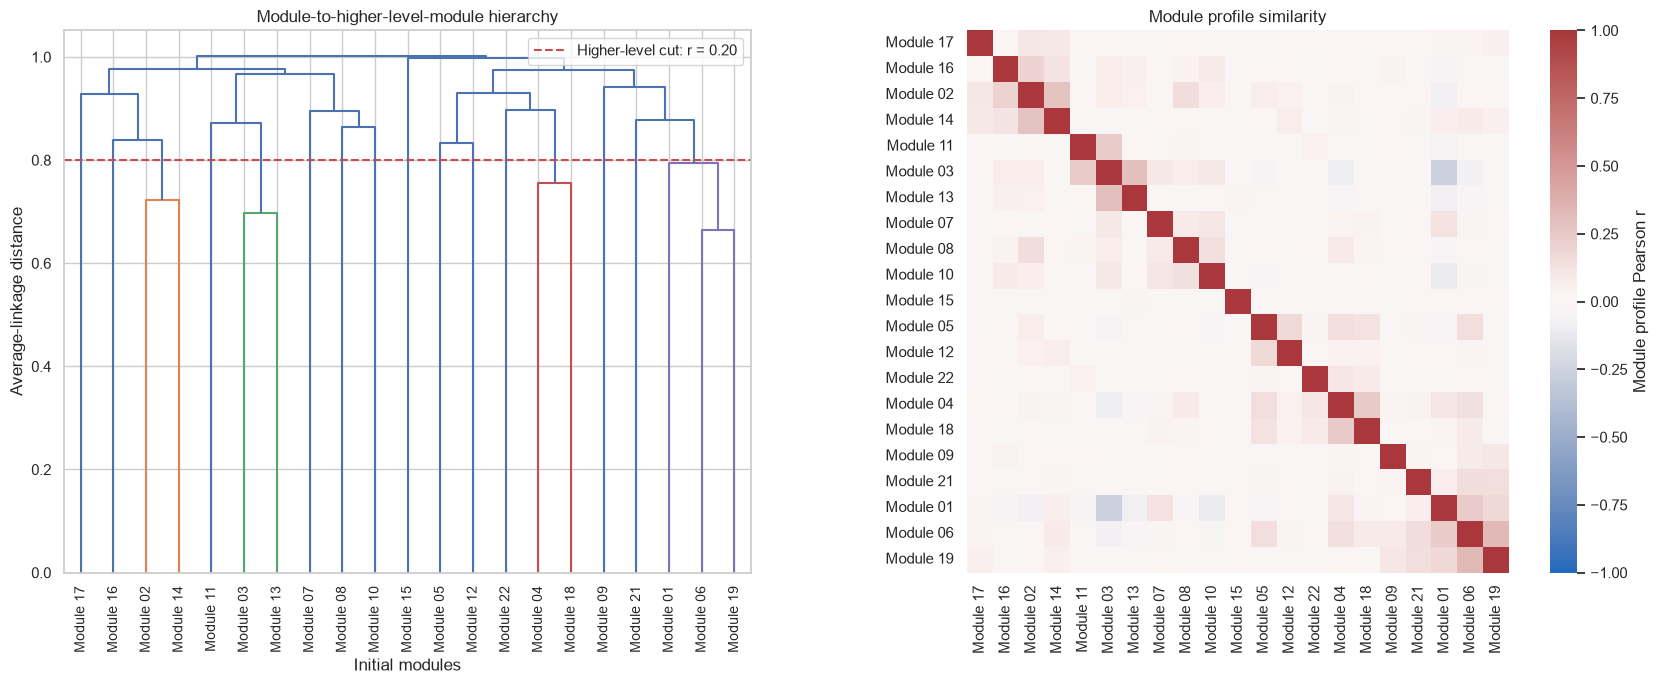

In [10]:
HIGHER_LEVEL_DISTANCE_CUTOFF = 0.80
MIN_REFINED_MODULE_SIZE = 2

refined_sizes = wta_assignment.loc[wta_assignment["winner_module"] != "Unassigned", "winner_module"].value_counts()
refined_modules = refined_sizes[refined_sizes >= MIN_REFINED_MODULE_SIZE].index.tolist()
module_gene_indices = {
    module_name: np.flatnonzero(wta_assignment["winner_module"].to_numpy() == module_name)
    for module_name in refined_modules
}

standardized_expression = (module_expression - module_expression.mean(axis=0)) / module_expression.std(axis=0)
module_profiles = np.column_stack(
    [standardized_expression[:, module_gene_indices[module_name]].mean(axis=1) for module_name in refined_modules]
 )
module_profile_correlation = np.corrcoef(module_profiles, rowvar=False)
module_profile_correlation = np.nan_to_num(module_profile_correlation, nan=0.0)
np.fill_diagonal(module_profile_correlation, 1.0)
module_profile_distance = np.clip(1 - module_profile_correlation, 0, 2)
higher_level_linkage = linkage(squareform(module_profile_distance, checks=False), method="average")
higher_level_labels = fcluster(
    higher_level_linkage, t=HIGHER_LEVEL_DISTANCE_CUTOFF, criterion="distance"
 )

within_module_correlation = {}
for module_name, gene_indices in module_gene_indices.items():
    if len(gene_indices) == 2:
        within_module_correlation[module_name] = module_correlation[gene_indices[0], gene_indices[1]]
    else:
        submatrix = module_correlation[np.ix_(gene_indices, gene_indices)]
        within_module_correlation[module_name] = submatrix[np.triu_indices_from(submatrix, k=1)].mean()

module_quality = pd.DataFrame(
    {
        "module": refined_modules,
        "n_genes": [len(module_gene_indices[module_name]) for module_name in refined_modules],
        "mean_within_module_r": [within_module_correlation[module_name] for module_name in refined_modules],
        "higher_level_module": higher_level_labels,
    }
)
module_quality["max_cross_module_r"] = [
    np.max(np.delete(module_profile_correlation[index], index))
    for index in range(len(refined_modules))
 ]
module_quality["separation"] = module_quality["mean_within_module_r"] - module_quality["max_cross_module_r"]
module_quality = module_quality.sort_values("n_genes", ascending=False).reset_index(drop=True)

print(f"Refined modules with >= {MIN_REFINED_MODULE_SIZE} genes: {len(refined_modules)}")
print(f"Higher-level modules: {module_quality['higher_level_module'].nunique()}")
display(module_quality.round(3))

fig, axes = plt.subplots(1, 2, figsize=(17, 7), gridspec_kw={"width_ratios": [1, 1.2]})
dendrogram(
    higher_level_linkage,
    labels=refined_modules,
    color_threshold=HIGHER_LEVEL_DISTANCE_CUTOFF,
    leaf_rotation=90,
    ax=axes[0],
 )
axes[0].axhline(HIGHER_LEVEL_DISTANCE_CUTOFF, color="#c44e52", linestyle="--", label="Higher-level cut: r = 0.20")
axes[0].set(title="Module-to-higher-level-module hierarchy", xlabel="Initial modules", ylabel="Average-linkage distance")
axes[0].legend()

ordered_modules = dendrogram(higher_level_linkage, no_plot=True, labels=refined_modules)["ivl"]
ordered_indices = [refined_modules.index(module_name) for module_name in ordered_modules]
sns.heatmap(
    module_profile_correlation[np.ix_(ordered_indices, ordered_indices)],
    xticklabels=ordered_modules,
    yticklabels=ordered_modules,
    cmap="vlag", center=0, vmin=-1, vmax=1, square=True,
    cbar_kws={"label": "Module profile Pearson r"},
    ax=axes[1],
 )
axes[1].set(title="Module profile similarity")
plt.tight_layout()
plt.show()

Modules with observed genes and masked targets: 16 / 21
Reference-supported targets assigned to modules: 100 / 100


,module,n_genes,observed_genes,masked_targets,reference_supported_targets,mean_affinity,mean_specificity,usable_for_reconstruction
0,Module 01,89,62,27,27,0.250,0.125,True
1,Module 02,30,17,13,13,0.260,0.130,True
2,Module 03,27,19,8,8,0.215,0.107,True
3,Module 05,21,13,8,8,0.244,0.159,True
4,Module 04,20,14,6,6,0.252,0.116,True
5,Module 07,12,6,6,6,0.245,0.106,True
6,Module 08,6,3,3,3,0.293,0.166,True
7,Module 06,17,15,2,2,0.250,0.124,True
8,Module 09,5,3,2,2,0.440,0.374,True
9,Module 12,5,4,1,1,0.284,0.206,True


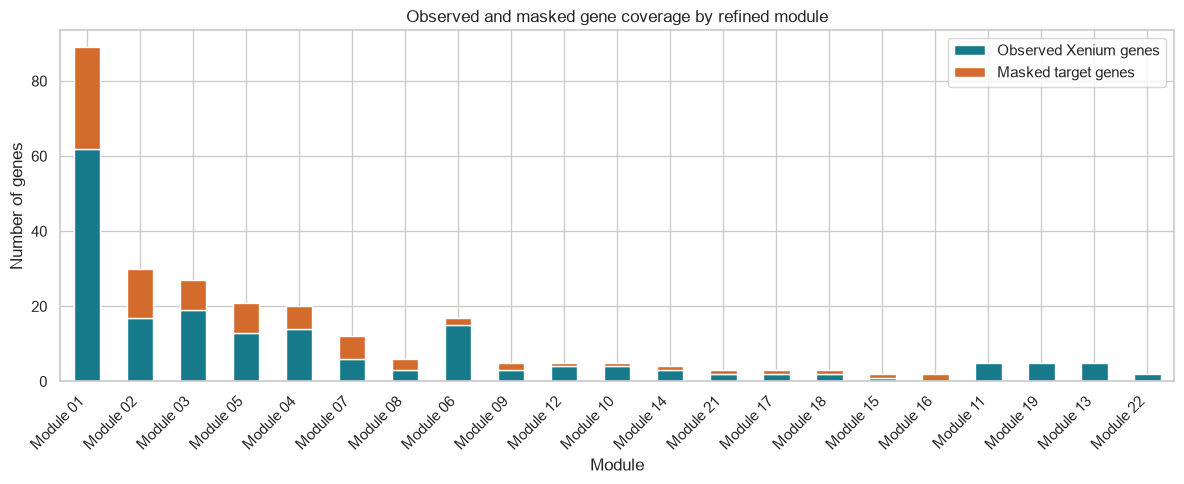

In [11]:
wta_assignment["is_observed_xenium"] = wta_assignment["gene"].isin(observed_gene_set)
wta_assignment["is_masked_target"] = wta_assignment["gene"].isin(target_gene_set)
wta_assignment["is_reference_supported_target"] = (
    wta_assignment["is_masked_target"] & wta_assignment["gene"].isin(shared_targets)
 )

module_coverage = (
    wta_assignment.loc[wta_assignment["winner_module"] != "Unassigned"]
    .groupby("winner_module", observed=True)
    .agg(
        n_genes=("gene", "size"),
        observed_genes=("is_observed_xenium", "sum"),
        masked_targets=("is_masked_target", "sum"),
        reference_supported_targets=("is_reference_supported_target", "sum"),
        mean_affinity=("winning_affinity", "mean"),
        mean_specificity=("specificity", "mean"),
    )
    .reindex(refined_modules)
    .reset_index()
    .rename(columns={"winner_module": "module"})
 )
module_coverage["usable_for_reconstruction"] = (
    (module_coverage["observed_genes"] > 0) & (module_coverage["masked_targets"] > 0)
 )
module_coverage = module_coverage.sort_values(
    ["usable_for_reconstruction", "masked_targets", "observed_genes"], ascending=False
 ).reset_index(drop=True)

print(f"Modules with observed genes and masked targets: {module_coverage['usable_for_reconstruction'].sum()} / {len(module_coverage)}")
print(f"Reference-supported targets assigned to modules: {wta_assignment['is_reference_supported_target'].sum()} / {len(shared_targets)}")
display(module_coverage.round(3))

coverage_plot = module_coverage.set_index("module")[["observed_genes", "masked_targets"]]
fig, ax = plt.subplots(figsize=(12, 5))
coverage_plot.plot(kind="bar", stacked=True, color=["#167a8b", "#d36b2d"], ax=ax)
ax.set(title="Observed and masked gene coverage by refined module", xlabel="Module", ylabel="Number of genes")
ax.legend(["Observed Xenium genes", "Masked target genes"], frameon=True)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Reconstruction modules: 16
Observed expression features: 208
Module features: 16
Spatial module features: 16
Model-ready student features: (166363, 240)


,module,feature_variance
3,Module 05,1.807518
0,Module 01,1.162469
1,Module 02,1.053002
2,Module 03,1.041487
5,Module 07,1.023404
8,Module 09,0.958015
7,Module 06,0.668110
4,Module 04,0.623920
13,Module 17,0.413935
10,Module 10,0.347334


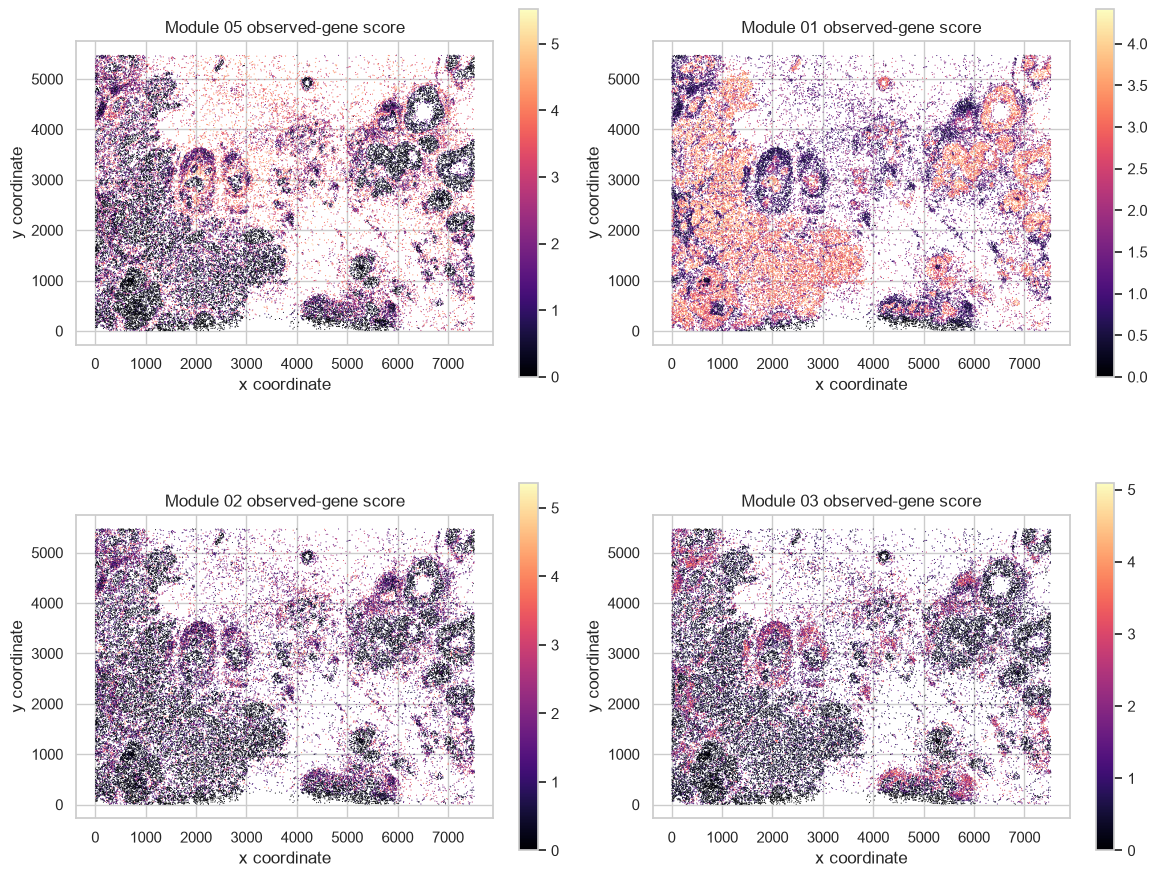

In [12]:
from scipy.spatial import cKDTree

reconstruction_modules = module_coverage.loc[module_coverage["usable_for_reconstruction"], "module"].tolist()
observed_column_lookup = {gene: index for index, gene in enumerate(observed_genes.str.upper())}
module_observed_columns = {}
for module_name in reconstruction_modules:
    module_genes = wta_assignment.loc[wta_assignment["winner_module"] == module_name, "gene"]
    module_observed_columns[module_name] = [
        observed_column_lookup[gene] for gene in module_genes if gene in observed_column_lookup
    ]

normalized_observed = np.log1p(X_observed * (1e4 / np.maximum(cell_total, 1))[:, None])
xenium_module_features = np.column_stack(
    [normalized_observed[:, module_observed_columns[module_name]].mean(axis=1) for module_name in reconstruction_modules]
 ).astype(np.float32)

SPATIAL_K = 12
spatial_tree = cKDTree(coordinates)
_, spatial_neighbor_indices = spatial_tree.query(coordinates, k=SPATIAL_K + 1)
spatial_neighbor_indices = spatial_neighbor_indices[:, 1:]
spatial_module_features = xenium_module_features[spatial_neighbor_indices].mean(axis=1).astype(np.float32)
student_features = np.hstack([normalized_observed, xenium_module_features, spatial_module_features]).astype(np.float32)

print(f"Reconstruction modules: {len(reconstruction_modules)}")
print(f"Observed expression features: {normalized_observed.shape[1]}")
print(f"Module features: {xenium_module_features.shape[1]}")
print(f"Spatial module features: {spatial_module_features.shape[1]}")
print(f"Model-ready student features: {student_features.shape}")

feature_variance = xenium_module_features.var(axis=0)
display(pd.DataFrame({"module": reconstruction_modules, "feature_variance": feature_variance}).sort_values("feature_variance", ascending=False))

top_module_indices = np.argsort(feature_variance)[-4:][::-1]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for axis, module_index in zip(axes.ravel(), top_module_indices):
    points = axis.scatter(
        coordinates[sample_index, 0], coordinates[sample_index, 1],
        c=xenium_module_features[sample_index, module_index],
        s=0.6, cmap="magma", linewidths=0, rasterized=True,
    )
    axis.set(title=f"{reconstruction_modules[module_index]} observed-gene score", xlabel="x coordinate", ylabel="y coordinate", aspect="equal")
    fig.colorbar(points, ax=axis, shrink=0.75)
plt.tight_layout()
plt.show()

In [13]:
PSEUDO_MASK_FRACTION = 0.20
VALIDATION_FRACTION = 0.20
split_rng = np.random.default_rng(2026)

pseudo_target_genes = []
for module_name in reconstruction_modules:
    module_observed_genes = wta_assignment.loc[
        (wta_assignment["winner_module"] == module_name) & wta_assignment["is_observed_xenium"], "gene"
    ].to_numpy()
    n_to_mask = min(
        max(1, int(np.floor(len(module_observed_genes) * PSEUDO_MASK_FRACTION))),
        max(0, len(module_observed_genes) - 1),
    )
    if n_to_mask > 0:
        pseudo_target_genes.extend(split_rng.choice(module_observed_genes, size=n_to_mask, replace=False))

pseudo_target_genes = pd.Index(sorted(set(pseudo_target_genes)), name="pseudo_target_gene")
pseudo_observed_genes = observed_genes[~observed_genes.str.upper().isin(pseudo_target_genes)]
pseudo_target_columns = [observed_column_lookup[gene] for gene in pseudo_target_genes]
pseudo_target_matrix = normalized_observed[:, pseudo_target_columns].astype(np.float32)

all_cells = np.arange(adata.n_obs)
split_rng.shuffle(all_cells)
n_validation = int(adata.n_obs * VALIDATION_FRACTION)
validation_cell_indices = np.sort(all_cells[:n_validation])
training_cell_indices = np.sort(all_cells[n_validation:])

pseudo_mask_summary = pd.DataFrame(
    {
        "item": ["Pseudo-masked genes", "Remaining observed genes", "Training cells", "Validation cells"],
        "value": [
            len(pseudo_target_genes),
            len(pseudo_observed_genes),
            len(training_cell_indices),
            len(validation_cell_indices),
        ],
    }
)
display(pseudo_mask_summary)
display(
    wta_assignment.loc[wta_assignment["gene"].isin(pseudo_target_genes), ["gene", "winner_module", "winning_affinity", "specificity"]]
    .sort_values(["winner_module", "gene"])
    .reset_index(drop=True)
 )

assert not set(pseudo_target_genes).intersection(pseudo_observed_genes.str.upper())
assert pseudo_target_matrix.shape == (adata.n_obs, len(pseudo_target_genes))
assert len(np.intersect1d(training_cell_indices, validation_cell_indices)) == 0

,item,value
0,Pseudo-masked genes,34
1,Remaining observed genes,174
2,Training cells,133091
3,Validation cells,33272


,gene,winner_module,winning_affinity,specificity
0,ADAM9,Module 01,0.223958,0.100672
1,BACE2,Module 01,0.161135,0.031398
2,CLDN4,Module 01,0.353818,0.183695
3,FOXA1,Module 01,0.367975,0.225656
4,FSTL3,Module 01,0.119221,0.039901
5,KLF5,Module 01,0.286457,0.143392
6,NARS,Module 01,0.253603,0.130364
7,QARS,Module 01,0.241029,0.122624
8,SERHL2,Module 01,0.249927,0.140143
9,SRPK1,Module 01,0.242952,0.126058


Ridge baseline mean PCC: 0.4178
Ridge baseline median PCC: 0.4436


,gene,pcc,module
0,TACSTD2,0.747872,Module 01
1,FOXA1,0.746048,Module 01
2,SERHL2,0.647732,Module 01
3,CD93,0.621985,Module 04
4,IL2RG,0.614676,Module 03
5,FCER1G,0.587075,Module 02
6,GPR183,0.554077,Module 03
7,CD3D,0.544189,Module 03
8,PDK4,0.532598,Module 02
9,CLDN4,0.530636,Module 01


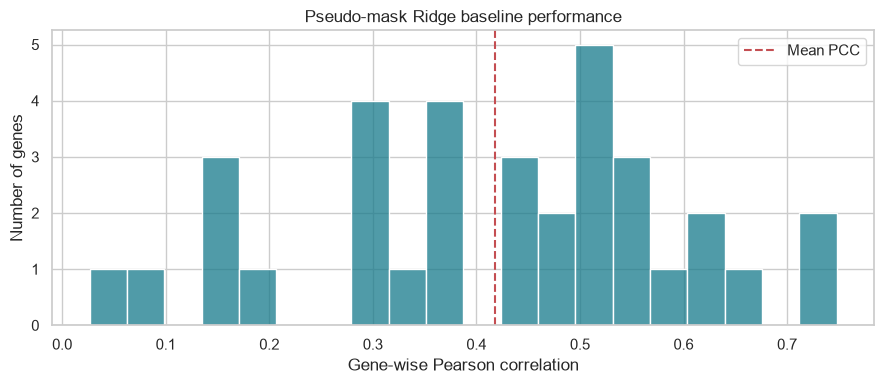

In [14]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

pseudo_observed_columns = [
    observed_column_lookup[gene] for gene in pseudo_observed_genes.str.upper()
 ]
pseudo_observed_counts = X_observed[:, pseudo_observed_columns]
pseudo_library_size = np.maximum(pseudo_observed_counts.sum(axis=1), 1)
pseudo_observed_features = np.log1p(
    pseudo_observed_counts * (1e4 / pseudo_library_size)[:, None]
 ).astype(np.float32)
pseudo_target_matrix = np.log1p(
    X_observed[:, pseudo_target_columns] * (1e4 / pseudo_library_size)[:, None]
 ).astype(np.float32)

pseudo_module_features = np.column_stack(
    [
        pseudo_observed_features[:, [
            list(pseudo_observed_genes.str.upper()).index(gene)
            for gene in wta_assignment.loc[
                (wta_assignment["winner_module"] == module_name) &
                wta_assignment["gene"].isin(pseudo_observed_genes.str.upper()),
                "gene",
            ]
        ]].mean(axis=1)
        for module_name in reconstruction_modules
    ]
 ).astype(np.float32)
pseudo_spatial_module_features = pseudo_module_features[spatial_neighbor_indices].mean(axis=1).astype(np.float32)
pseudo_student_features = np.hstack(
    [pseudo_observed_features, pseudo_module_features, pseudo_spatial_module_features]
 ).astype(np.float32)

feature_scaler = StandardScaler()
X_train = feature_scaler.fit_transform(pseudo_student_features[training_cell_indices])
X_validation = feature_scaler.transform(pseudo_student_features[validation_cell_indices])
y_train = pseudo_target_matrix[training_cell_indices]
y_validation = pseudo_target_matrix[validation_cell_indices]

ridge_model = Ridge(alpha=10.0)
ridge_model.fit(X_train, y_train)
ridge_prediction = ridge_model.predict(X_validation)

prediction_centered = ridge_prediction - ridge_prediction.mean(axis=0)
target_centered = y_validation - y_validation.mean(axis=0)
per_gene_pcc = (prediction_centered * target_centered).sum(axis=0) / np.sqrt(
    (prediction_centered**2).sum(axis=0) * (target_centered**2).sum(axis=0)
 )
baseline_metrics = pd.DataFrame(
    {
        "gene": pseudo_target_genes,
        "pcc": per_gene_pcc,
        "module": wta_assignment.set_index("gene").loc[pseudo_target_genes, "winner_module"].to_numpy(),
    }
).sort_values("pcc", ascending=False)

print(f"Ridge baseline mean PCC: {baseline_metrics['pcc'].mean():.4f}")
print(f"Ridge baseline median PCC: {baseline_metrics['pcc'].median():.4f}")
display(baseline_metrics.reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(baseline_metrics["pcc"], bins=20, color="#167a8b", ax=ax)
ax.axvline(baseline_metrics["pcc"].mean(), color="#c44e52", linestyle="--", label="Mean PCC")
ax.set(title="Pseudo-mask Ridge baseline performance", xlabel="Gene-wise Pearson correlation", ylabel="Number of genes")
ax.legend()
plt.tight_layout()
plt.show()

Reference-trained transfer baseline mean PCC: 0.3425
Reference-trained transfer baseline median PCC: 0.3736
Reference input genes: 173; evaluated pseudo-targets: 34


,gene,pcc
0,FOXA1,0.714799
1,TACSTD2,0.693445
2,SERHL2,0.598847
3,IL2RG,0.586045
4,CD93,0.579734
5,CD3D,0.517522
6,FCER1G,0.507169
7,CLDN4,0.496762
8,GPR183,0.495347
9,KLF5,0.473965


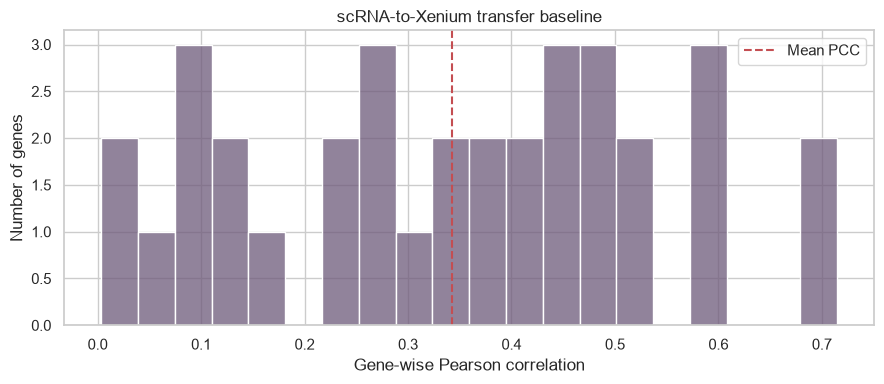

In [15]:
reference_column_lookup = {gene: index for index, gene in enumerate(reference_subset.var_names)}
transfer_input_genes = [
    gene for gene in pseudo_observed_genes.str.upper() if gene in reference_column_lookup
 ]
transfer_target_genes = [
    gene for gene in pseudo_target_genes if gene in reference_column_lookup
 ]
transfer_input_reference_columns = [reference_column_lookup[gene] for gene in transfer_input_genes]
transfer_target_reference_columns = [reference_column_lookup[gene] for gene in transfer_target_genes]
transfer_input_xenium_columns = [observed_column_lookup[gene] for gene in transfer_input_genes]
transfer_target_pseudo_columns = [list(pseudo_target_genes).index(gene) for gene in transfer_target_genes]

reference_transfer_input = reference_expression[:, transfer_input_reference_columns]
reference_transfer_target = reference_expression[:, transfer_target_reference_columns]
xenium_transfer_input = np.log1p(
    X_observed[:, transfer_input_xenium_columns] * (1e4 / np.maximum(X_observed[:, transfer_input_xenium_columns].sum(axis=1), 1))[:, None]
 ).astype(np.float32)
xenium_transfer_target = pseudo_target_matrix[:, transfer_target_pseudo_columns]

transfer_scaler = StandardScaler()
transfer_model = Ridge(alpha=10.0)
transfer_model.fit(transfer_scaler.fit_transform(reference_transfer_input), reference_transfer_target)
transfer_prediction = transfer_model.predict(
    transfer_scaler.transform(xenium_transfer_input[validation_cell_indices])
 )
transfer_truth = xenium_transfer_target[validation_cell_indices]
transfer_prediction_centered = transfer_prediction - transfer_prediction.mean(axis=0)
transfer_truth_centered = transfer_truth - transfer_truth.mean(axis=0)
transfer_pcc = (transfer_prediction_centered * transfer_truth_centered).sum(axis=0) / np.sqrt(
    (transfer_prediction_centered**2).sum(axis=0) * (transfer_truth_centered**2).sum(axis=0)
 )
transfer_metrics = pd.DataFrame({"gene": transfer_target_genes, "pcc": transfer_pcc}).sort_values("pcc", ascending=False)

print(f"Reference-trained transfer baseline mean PCC: {transfer_metrics['pcc'].mean():.4f}")
print(f"Reference-trained transfer baseline median PCC: {transfer_metrics['pcc'].median():.4f}")
print(f"Reference input genes: {len(transfer_input_genes)}; evaluated pseudo-targets: {len(transfer_target_genes)}")
display(transfer_metrics.reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(transfer_metrics["pcc"], bins=20, color="#6d597a", ax=ax)
ax.axvline(transfer_metrics["pcc"].mean(), color="#c44e52", linestyle="--", label="Mean PCC")
ax.set(title="scRNA-to-Xenium transfer baseline", xlabel="Gene-wise Pearson correlation", ylabel="Number of genes")
ax.legend()
plt.tight_layout()
plt.show()

Best spatial neighbor weight: 0.5
Best smoothed transfer mean PCC: 0.3634


,neighbor_weight,mean_pcc
0,0.0,0.3425
1,0.1,0.3481
2,0.2,0.3534
3,0.3,0.3580
4,0.4,0.3616
5,0.5,0.3634
6,0.6,0.3626
7,0.7,0.3581
8,0.8,0.3485
9,0.9,0.3331


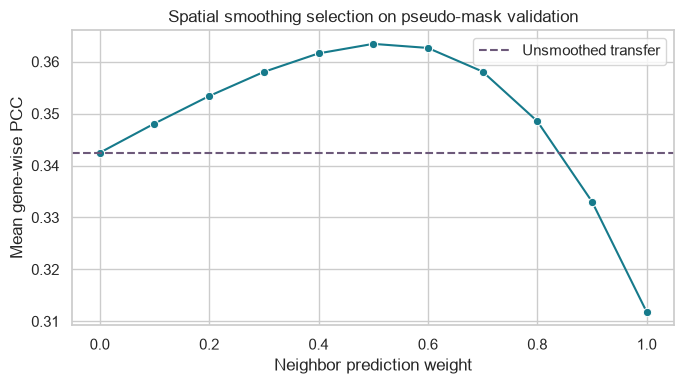

In [16]:
transfer_prediction_all = transfer_model.predict(transfer_scaler.transform(xenium_transfer_input)).astype(np.float32)
transfer_neighbor_prediction = transfer_prediction_all[spatial_neighbor_indices].mean(axis=1)

def mean_gene_pcc(prediction, truth):
    prediction_centered = prediction - prediction.mean(axis=0)
    truth_centered = truth - truth.mean(axis=0)
    pcc = (prediction_centered * truth_centered).sum(axis=0) / np.sqrt(
        (prediction_centered**2).sum(axis=0) * (truth_centered**2).sum(axis=0)
    )
    return np.nanmean(pcc), pcc

smoothing_grid = np.linspace(0, 1, 11)
smoothing_results = []
for smoothing_weight in smoothing_grid:
    smoothed_prediction = (
        (1 - smoothing_weight) * transfer_prediction_all[validation_cell_indices]
        + smoothing_weight * transfer_neighbor_prediction[validation_cell_indices]
    )
    mean_pcc, _ = mean_gene_pcc(smoothed_prediction, transfer_truth)
    smoothing_results.append({"neighbor_weight": smoothing_weight, "mean_pcc": mean_pcc})
smoothing_results = pd.DataFrame(smoothing_results)
best_smoothing_weight = smoothing_results.loc[smoothing_results["mean_pcc"].idxmax(), "neighbor_weight"]
best_smoothed_prediction = (
    (1 - best_smoothing_weight) * transfer_prediction_all[validation_cell_indices]
    + best_smoothing_weight * transfer_neighbor_prediction[validation_cell_indices]
 )
best_smoothed_mean_pcc, best_smoothed_pcc = mean_gene_pcc(best_smoothed_prediction, transfer_truth)

print(f"Best spatial neighbor weight: {best_smoothing_weight:.1f}")
print(f"Best smoothed transfer mean PCC: {best_smoothed_mean_pcc:.4f}")
display(smoothing_results.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(data=smoothing_results, x="neighbor_weight", y="mean_pcc", marker="o", color="#167a8b", ax=ax)
ax.axhline(transfer_metrics["pcc"].mean(), color="#6d597a", linestyle="--", label="Unsmoothed transfer")
ax.set(title="Spatial smoothing selection on pseudo-mask validation", xlabel="Neighbor prediction weight", ylabel="Mean gene-wise PCC")
ax.legend()
plt.tight_layout()
plt.show()

In [32]:
FINAL_SMOOTHING_WEIGHT = float(best_smoothing_weight)
SUBMISSION_OUTPUT_PATH = DATA_DIR / "submission_reference_ridge_spatial.csv"

final_input_genes = [gene for gene in observed_genes.str.upper() if gene in reference_column_lookup]
final_target_genes = [gene for gene in target_genes.str.upper() if gene in reference_column_lookup]
unsupported_target_genes = [gene for gene in target_genes.str.upper() if gene not in reference_column_lookup]

final_reference_input_columns = [reference_column_lookup[gene] for gene in final_input_genes]
final_reference_target_columns = [reference_column_lookup[gene] for gene in final_target_genes]
final_xenium_input_columns = [observed_column_lookup[gene] for gene in final_input_genes]
final_xenium_input = X_observed[:, final_xenium_input_columns].astype(np.float32)

final_scaler = StandardScaler()
final_model = Ridge(alpha=10.0)
final_model.fit(
    final_scaler.fit_transform(reference_expression[:, final_reference_input_columns]),
    reference_expression[:, final_reference_target_columns],
 )
final_expression_prediction = final_model.predict(
    final_scaler.transform(final_xenium_input)
).astype(np.float32)
final_neighbor_prediction = final_expression_prediction[spatial_neighbor_indices].mean(axis=1)
final_expression_prediction = np.maximum(
    (1 - FINAL_SMOOTHING_WEIGHT) * final_expression_prediction
    + FINAL_SMOOTHING_WEIGHT * final_neighbor_prediction,
    0,
 ).astype(np.float32)

submission_template = pd.read_csv(SUBMISSION_PATH, usecols=["Spot_id"])
prediction_matrix = np.zeros((adata.n_obs, len(target_genes)), dtype=np.float32)
target_positions = pd.Index(target_genes.str.upper()).get_indexer(final_target_genes)
assert (target_positions >= 0).all()
prediction_matrix[:, target_positions] = final_expression_prediction
submission = pd.concat(
    [
        submission_template.reset_index(drop=True),
        pd.DataFrame(prediction_matrix, columns=target_genes),
    ],
    axis=1,
 )

assert submission.shape == (adata.n_obs, len(target_genes) + 1)
assert submission.columns.tolist() == submission_columns
assert submission["Spot_id"].equals(submission_template["Spot_id"])
assert np.isfinite(submission.iloc[:, 1:].to_numpy()).all()
assert (submission.iloc[:, 1:].to_numpy() >= 0).all()
submission.to_csv(SUBMISSION_OUTPUT_PATH, index=False)

print(f"Saved submission: {SUBMISSION_OUTPUT_PATH}")
print(f"Submission shape: {submission.shape}")
print(f"Reference-supported targets predicted: {len(final_target_genes)}")
print(f"Unsupported targets set to zero: {unsupported_target_genes}")
print(f"Predicted expression p50/p95: {np.percentile(final_expression_prediction, [50, 95])}")
print(f"Observed expression p50/p95: {np.percentile(final_xenium_input, [50, 95])}")
display(submission.iloc[:3, :8])

Saved submission: /home/Data_Drive_8TB/kykim/7. Kaggle/Imputation_Benchmarking_(Xenium_Fold_1)/submission_reference_ridge_spatial.csv
Submission shape: (166363, 106)
Reference-supported targets predicted: 100
Unsupported targets set to zero: ['AKR1C1', 'ANGPT2', 'BTNL9', 'CD8B', 'POLR2J3']
Predicted expression p50/p95: [0.53071642 3.24470863]
Observed expression p50/p95: [0.         5.19057322]


,Spot_id,ACTA2,ACTG2,ADH1B,AHSP,AIF1,AKR1C1,AKR1C3
0,0,0.137448,0.000000,0.0,0.068017,0.0,0.0,0.000000
1,1,0.079231,0.049522,0.0,0.000000,0.0,0.0,0.037853
2,2,0.030744,0.000000,0.0,0.064516,0.0,0.0,0.000000


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

REFERENCE_TEST_FRACTION = 0.20
RIDGE_ALPHA = 10.0
SPLIT_SEED = 2026

reference_column_lookup = {gene: index for index, gene in enumerate(reference_subset.var_names)}
ridge_input_genes = [gene for gene in observed_genes.str.upper() if gene in reference_column_lookup]
ridge_target_genes = [gene for gene in target_genes.str.upper() if gene in reference_column_lookup]
ridge_input_columns = [reference_column_lookup[gene] for gene in ridge_input_genes]
ridge_target_columns = [reference_column_lookup[gene] for gene in ridge_target_genes]
X_reference_ridge = reference_expression[:, ridge_input_columns].astype(np.float32)
y_reference_ridge = reference_expression[:, ridge_target_columns].astype(np.float32)

train_indices, test_indices = train_test_split(
    np.arange(X_reference_ridge.shape[0]),
    test_size=REFERENCE_TEST_FRACTION,
    random_state=SPLIT_SEED,
    shuffle=True,
 )
ridge_scaler = StandardScaler()
X_reference_train = ridge_scaler.fit_transform(X_reference_ridge[train_indices])
X_reference_test = ridge_scaler.transform(X_reference_ridge[test_indices])
ridge_reference_model = Ridge(alpha=RIDGE_ALPHA)
ridge_reference_model.fit(X_reference_train, y_reference_ridge[train_indices])
ridge_reference_prediction = ridge_reference_model.predict(X_reference_test)

def gene_wise_pcc(prediction, truth):
    prediction_centered = prediction - prediction.mean(axis=0, keepdims=True)
    truth_centered = truth - truth.mean(axis=0, keepdims=True)
    denominator = np.sqrt(
        np.square(prediction_centered).sum(axis=0) * np.square(truth_centered).sum(axis=0)
    )
    return np.divide(
        (prediction_centered * truth_centered).sum(axis=0),
        denominator,
        out=np.full(prediction.shape[1], np.nan),
        where=denominator > 0,
    )

reference_test_pcc = gene_wise_pcc(ridge_reference_prediction, y_reference_ridge[test_indices])
reference_test_r2 = r2_score(y_reference_ridge[test_indices], ridge_reference_prediction, multioutput="raw_values")
reference_test_mse = mean_squared_error(y_reference_ridge[test_indices], ridge_reference_prediction, multioutput="raw_values")
reference_ridge_metrics = pd.DataFrame(
    {
        "gene": ridge_target_genes,
        "pcc": reference_test_pcc,
        "r2": reference_test_r2,
        "mse": reference_test_mse,
    }
).sort_values("pcc", ascending=False)

print(f"scRNA Ridge split: {len(train_indices):,} train / {len(test_indices):,} test cells")
print(f"Input genes: {len(ridge_input_genes)}; evaluated target genes: {len(ridge_target_genes)}")
print(f"Hold-out mean gene-wise PCC: {reference_ridge_metrics['pcc'].mean():.4f}")
print(f"Hold-out median gene-wise PCC: {reference_ridge_metrics['pcc'].median():.4f}")
print(f"Hold-out mean gene-wise R2: {reference_ridge_metrics['r2'].mean():.4f}")
display(reference_ridge_metrics.reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(reference_ridge_metrics["pcc"], bins=30, color="#167a8b", ax=axes[0])
axes[0].axvline(reference_ridge_metrics["pcc"].mean(), color="#c44e52", linestyle="--", label="Mean PCC")
axes[0].set(title="Ridge evaluation on held-out scRNA cells", xlabel="Gene-wise PCC")
axes[0].legend()
sns.scatterplot(
    x=y_reference_ridge[test_indices].ravel(),
    y=ridge_reference_prediction.ravel(),
    s=2, alpha=0.08, color="#6d597a", ax=axes[1],
 )
axes[1].plot([0, 10], [0, 10], color="#c44e52", linestyle="--")
axes[1].set(title="Observed vs predicted scRNA target expression", xlabel="Observed log-normalized expression", ylabel="Ridge prediction")
plt.tight_layout()
plt.show()